In [1]:
# Install & Import Library !pip install pandas numpy matplotlib seaborn plotly
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

print('Library berhasil diimport!')

Library berhasil diimport!


In [2]:
#Load data mentah
df = pd.read_csv("/content/rfm_raw.csv")
print('Shape', df.shape)
print('Column', df.columns.to_list())
print()
df.info()

Shape (10000, 11)
Column ['CustomerID', 'Gender', 'Age', 'Country', 'City', 'BranchID', 'PaymentType', 'LastPurchaseDate', 'Recency', 'Frequency', 'Monetary']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        10000 non-null  int64  
 1   Gender            9812 non-null   object 
 2   Age               10000 non-null  int64  
 3   Country           10000 non-null  object 
 4   City              10000 non-null  object 
 5   BranchID          10000 non-null  object 
 6   PaymentType       10000 non-null  object 
 7   LastPurchaseDate  10000 non-null  object 
 8   Recency           10000 non-null  int64  
 9   Frequency         10000 non-null  int64  
 10  Monetary          10000 non-null  float64
dtypes: float64(1), int64(4), object(6)
memory usage: 859.5+ KB


In [16]:
# Statistik Deskriptif Data Mentah
print('=== Statistik Data MENTAH (sebelum cleaning) ===')
df [['Recency', 'Frequency', 'Monetary', 'Age']].describe().round(2)

=== Statistik Data MENTAH (sebelum cleaning) ===


,Recency,Frequency,Monetary,Age
count,10000.00,10000.00,10000.00,10000.00
mean,369.06,2.98,6378.29,49.71
std,211.46,1.72,25106.61,25.13
min,1.00,0.00,-69916.75,-10.00
25%,188.00,2.00,680.53,33.00
50%,370.00,3.00,1027.54,49.00
75%,553.00,4.00,1403.97,65.00
max,731.00,12.00,257773.52,150.00


In [4]:
# Audit Kualitas Data
print('=== AUDIT KUALITAS DATA ===')
print()
# 1. Missing values
print('[Missing value]')
print(df.isnull().sum())
print(f'Total Missing Value {df.isnull().sum().sum()} sel')
print()
# 2. Duplikat CustomerID
dup = df[df.duplicated(subset='CustomerID', keep=False)]
print(f'[Duplikat CustomerID]:{len(dup)} baris')
print()
# 3. Outlier Age (Age > 120 = anomali input data)
print(f'Age > 120: {(df['Age'] > 120).sum()} baris')
print(f'Age <= 0: {(df['Age'] <= 0).sum()} baris')
print()
# 4. Monetary tidak valid
print(f'Monetary <= 0: {(df["Monetary"] <= 0).sum()} baris')
print(f'Monetary isnull: {(df["Monetary"].isnull().sum())} baris')
print()

=== AUDIT KUALITAS DATA ===

[Missing value]
CustomerID            0
Gender              188
Age                   0
Country               0
City                  0
BranchID              0
PaymentType           0
LastPurchaseDate      0
Recency               0
Frequency             0
Monetary              0
dtype: int64
Total Missing Value 188 sel

[Duplikat CustomerID]:0 baris

Age > 120: 237 baris
Age <= 0: 247 baris

Monetary <= 0: 223 baris
Monetary isnull: 0 baris



In [5]:
# Eksekusi Cleaning
df_clean = df.copy()
n_before = len(df_clean)
print(f'Jumlah baris data sebelum cleaning: {n_before}')

# Step 1: Hapus duplikat CustomerID (pertahankan baris pertama)
df_clean = df_clean.drop_duplicates(
    subset='CustomerID',
    keep='first')
print(f'Jumlah baris data setelah duplikat CustomerID dihapus: {len(df_clean)}')
# Step 2: Hapus Age tidak wajar
df_clean = df_clean[
    (df_clean["Age"] >= 0) &
    (df_clean ["Age"]<= 120)]
print(f'Jumlah baris data setelah Age tidak wajar dihapus: {len(df_clean)}')
# Step 3: Hapus Monetary tidak wajar
df_clean = df_clean[df_clean["Monetary"] > 0]
print(f'Jumlah baris data setelah Monetary tidak wajar dihapus: {len(df_clean)}')
# Step 4: Reset index
df_clean = df_clean.reset_index(drop=True)
print(f'Jumlah baris data setelah index di reset: {len(df_clean)}')
print()
print(f'Data MENTAH  : {n_before} baris')
print(f'Data BERSIH  : {len(df_clean)} baris')
print(f'Total dihapus: {n_before - len(df_clean)} baris')

Jumlah baris data sebelum cleaning: 10000
Jumlah baris data setelah duplikat CustomerID dihapus: 10000
Jumlah baris data setelah Age tidak wajar dihapus: 9516
Jumlah baris data setelah Monetary tidak wajar dihapus: 9301
Jumlah baris data setelah index di reset: 9301

Data MENTAH  : 10000 baris
Data BERSIH  : 9301 baris
Total dihapus: 699 baris


In [6]:
# Verifikasi Distribusi Setelah Cleaning
df_clean[['Recency', 'Frequency', 'Monetary']].describe().round(2)

,Recency,Frequency,Monetary
count,9301.00,9301.00,9301.00
mean,369.46,2.99,6598.73
std,211.57,1.71,25439.73
min,1.00,0.00,0.85
25%,189.00,2.00,706.27
50%,371.00,3.00,1041.80
75%,554.00,4.00,1413.87
max,731.00,12.00,257773.52


In [7]:
# Sel 7: Hitung Skor R, F, M dengan pd.qcut

# --- R_Score: Recency DIBALIK ---
# Recency kecil (beli baru-baru ini) = skor TINGGI
# labels=[5,4,3,2,1] karena kuintil pertama (recency terkecil) = skor 5
df_clean['R_Score'] = pd.qcut(
    df_clean['Recency'],
    q=5,
    labels=[5,4,3,2,1],
    duplicates='drop'
    ).astype(int)

# --- F_Score: Frequency NORMAL ---
# Frequency tinggi = skor tinggi
df_clean['F_Score'] = pd.qcut(
    df_clean['Frequency'].rank(method='first'),
    q=5,
    labels=[1,2,3,4,5]
).astype(int)

# --- M_Score: Monetary NORMAL ---
# Monetary tinggi = skor tinggi
df_clean['M_Score'] = pd.qcut(df_clean['Monetary'], q=5, labels=[1,2,3,4,5], duplicates='drop').astype(int)

# Gabungkan menjadi RFM String Score
df_clean['RFM_Score'] = (
    df_clean['R_Score'].astype(str)+
    df_clean['F_Score'].astype(str)+
    df_clean['M_Score'].astype(str))

# RFM Total (3–15): makin tinggi = pelanggan makin berharga
df_clean['RFM_Total'] = (
    df_clean['R_Score'] +
    df_clean['F_Score'] +
    df_clean['M_Score'])

# Verifikasi distribusi skor
print('Verifikasi Distribusi Skor R_Score:')
print(df_clean['R_Score'].value_counts().sort_index())
print('Verifikasi Distribusi Skor F_Score:')
print(df_clean['F_Score'].value_counts().sort_index())
print('Verifikasi Distribusi Skor M_Score:')
print(df_clean['M_Score'].value_counts().sort_index())

Verifikasi Distribusi Skor R_Score:
R_Score
1    1857
2    1860
3    1860
4    1856
5    1868
Name: count, dtype: int64
Verifikasi Distribusi Skor F_Score:
F_Score
1    1861
2    1860
3    1860
4    1860
5    1860
Name: count, dtype: int64
Verifikasi Distribusi Skor M_Score:
M_Score
1    1861
2    1860
3    1860
4    1860
5    1860
Name: count, dtype: int64


In [8]:
# Sel 8: Validasi Skor
print('=== Validasi: Top 5 Champions (RFM_Total tertinggi) ===')
top5 = df_clean.nlargest(5, 'RFM_Total')[
    ['CustomerID','Recency','Frequency','Monetary','R_Score','F_Score','M_Score','RFM_Score']
]
print(top5.to_string())
print()
print('=== Validasi: Top 5 Lost Customers (RFM_Total terendah) ===')
bot5 = df_clean.nsmallest(5, 'RFM_Total')[
    ['CustomerID','Recency','Frequency','Monetary','R_Score','F_Score','M_Score','RFM_Score']
]
print(bot5.to_string())

=== Validasi: Top 5 Champions (RFM_Total tertinggi) ===
     CustomerID  Recency  Frequency   Monetary  R_Score  F_Score  M_Score RFM_Score
212   211905002       80          6   66294.05        5        5        5       555
338   328604791      104          5   87117.53        5        5        5       555
405   382719747      106          6    1843.05        5        5        5       555
606   607060613        1          7  180386.47        5        5        5       555
615   614016801       14          5    1614.00        5        5        5       555

=== Validasi: Top 5 Lost Customers (RFM_Total terendah) ===
     CustomerID  Recency  Frequency  Monetary  R_Score  F_Score  M_Score RFM_Score
149   150303962      658          0    210.09        1        1        1       111
424   398807232      665          1     98.98        1        1        1       111
528   520127968      614          1    460.13        1        1        1       111
686   696025529      636          1    584.05  

In [9]:
# Sel 9: Segmentasi Pelanggan
def rfm_segment(row):
  r = row['R_Score']
  f = row['F_Score']
  m = row['M_Score']

  # 1. CHAMPIONS (Pelanggan Terbaik)
  # Baru beli, sangat sering, dan belanja banyak.
  if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'

  # 2. LOYAL CUSTOMERS (Pelanggan Setia)
  # Sering membeli dan responsif terhadap promosi, meskipun tidak selalu baru-baru ini.
  elif r >= 3 and f >= 3:
        return 'Loyal Customers'

  # 3. POTENTIAL LOYALISTS (Pelanggan Baru Berpotensi)
  # Pembeli baru dengan frekuensi yang mulai meningkat dan nominal belanja bagus.
  elif r >= 4 and f >= 2:
        return 'Potential Loyalists'

  # 4. NEW CUSTOMERS (Pelanggan Baru)
  # Baru pertama kali membeli dengan frekuensi rendah (F=1).
  elif r >= 4 and f == 1:
        return 'New Customers'

  # 5. NEED ATTENTION (Butuh Perhatian)
  # Berada di zona aman (rata-rata), tetapi bisa hilang jika tidak diberi stimulus.
  elif r == 3 and f <= 2:
        return 'Need Attention'

  # 6. AT RISK (Beresiko Hilang)
  # Dulu sering belanja/loyal, tetapi sudah lama sekali tidak kembali belanja.
  elif r <= 2 and f >= 3:
        return 'At Risk'

  # 7. LOST / HIBERNATING (Pelanggan Hilang)
  # Skor terendah di semua aspek. Sudah lama tidak beli dan jarang beli.
  else:
        return 'Lost Customers'

df_clean['Segment'] = df_clean.apply(rfm_segment, axis=1)

# Value Tier berdasarkan kuintil Monetary (data bersih)
q75 = df_clean['Monetary'].quantile(0.75)
q50 = df_clean['Monetary'].quantile(0.50)
df_clean['Value_Tier'] = df_clean['Monetary'].apply(
    lambda m: 'High Value' if m >= q75 else ('Medium Value' if m >= q50 else 'Low Value')
)

# ringkasan per segmen
print('=== Ringkasan Per Segment ===')
summary = df_clean.groupby('Segment').agg(
    Total_Customer = ('CustomerID', 'count'),
    AVG_Recency = ('Recency', 'mean'),
    AVG_Frequency = ('Frequency', 'mean'),
    AVG_Monetary = ('Monetary', 'mean'),
    Total_Revenue = ('Monetary', 'sum')
).round(2).sort_values('Total_Revenue', ascending=False)
print(summary)

=== Ringkasan Per Segment ===
                     Total_Customer  AVG_Recency  AVG_Frequency  AVG_Monetary  \
Segment                                                                         
At Risk                        2243       592.30           4.04       7583.45   
Loyal Customers                2749       242.00           3.95       3996.53   
Lost Customers                 1474       585.17           1.38       6799.91   
Champions                       588       154.97           4.63      15420.36   
New Customers                   758       147.46           0.74       7276.18   
Need Attention                  708       370.42           1.38       6224.29   
Potential Loyalists             781       147.09           2.00       5590.61   

                     Total_Revenue  
Segment                             
At Risk                17009687.90  
Loyal Customers        10986457.14  
Lost Customers         10023073.88  
Champions               9067173.91  
New Customers     

In [10]:
 # Sel 10: Bar Chart Distribusi Segmen
seg_count = df_clean['Segment'].value_counts().reset_index()
seg_count.columns = ['Segment', 'Count']

fig = px.bar(seg_count, x='Segment', y='Count',
             color='Count', color_continuous_scale='Blues',
             title='Distribusi Pelanggan per Segmen RFM (Post-Cleaning)',
             text='Count')
fig.update_traces(textposition='outside')
fig.update_layout(xaxis_tickangle=-30, showlegend=False)
fig.show()

In [11]:
# Sel 11: Scatter Plot RFM
fig2 = px.scatter(df_clean, x='Recency', y='Monetary',
                  size='Frequency', color='Segment',
                  hover_data=['CustomerID','Country','RFM_Score'],
                  title='RFM Scatter: Recency vs Monetary (ukuran = Frequency)',
                  opacity=0.7)
fig2.show()

In [12]:
# Sel 12: Kontribusi per Segmen
fig3 = px.treemap(summary.reset_index(),
                  path=['Segment'],
                  values='Total_Revenue',
                  color='AVG_Monetary',
                  color_continuous_scale='Viridis',
                  title='Kontribusi Revenue per Segmen RFM')
fig3.show()

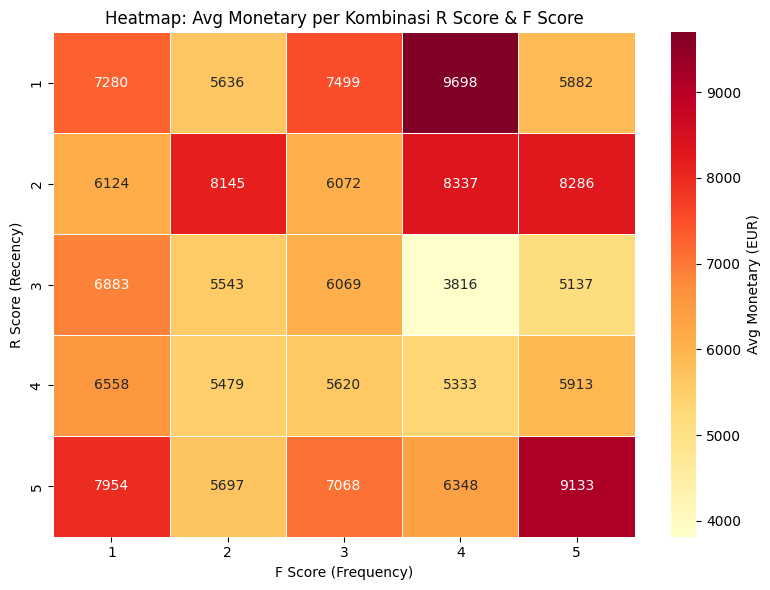

In [13]:
# Sel 13: Heatmap Rata-rata Monetary per Kombinasi R & F Score
pivot = df_clean.pivot_table(
    values='Monetary', index='R_Score', columns='F_Score', aggfunc='mean'
).round(0)

plt.figure(figsize=(8, 6))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Avg Monetary (EUR)'})
plt.title('Heatmap: Avg Monetary per Kombinasi R Score & F Score')
plt.xlabel('F Score (Frequency)')
plt.ylabel('R Score (Recency)')
plt.tight_layout()
plt.show()

In [14]:
# Sel 14: Donut Chart Persentase Pelanggan per Segmen
seg_count['Percentage'] = (seg_count['Count'] / seg_count['Count'].sum()) * 100

fig_donut = px.pie(seg_count,
                 values='Count',
                 names='Segment',
                 title='Distribusi Persentase Pelanggan per Segmen RFM',
                 hole=0.4,
                 color_discrete_sequence=px.colors.qualitative.Pastel)

fig_donut.update_traces(textposition='inside', textinfo='percent+label')
fig_donut.update_layout(showlegend=False)
fig_donut.show()

In [15]:
# Sel 15: Export ke rfm_segmented.csv
output_cols = [
    'CustomerID', 'Gender', 'Age', 'Country', 'City',
    'BranchID', 'PaymentType', 'LastPurchaseDate',
    'Recency', 'Frequency', 'Monetary',
    'R_Score', 'F_Score', 'M_Score',
    'RFM_Score', 'RFM_Total',
    'Segment', 'Value_Tier'
]

df_export = df_clean[output_cols]
df_export.to_csv('rfm_segmented_final.csv', index=False)

print(f'Export selesai: {len(df_export)} baris')
print(f'Kolom         : {df_export.columns.tolist()}')
print(f'Distribusi    :')
print(df_export['Segment'].value_counts())

# Download file dari Colab
from google.colab import files
files.download('rfm_segmented_final.csv')